# Data analysis with Pandas

A beginner-friendly walkthrough: **Series**, **DataFrame**, and loading common file formats. Run cells top to bottom.

## Introduction

**Pandas** is one of the most popular Python libraries for data analysis. According to [Wikipedia](https://en.wikipedia.org/wiki/Pandas_(software)), the name "Pandas" comes from the term "panel data", an econometrics concept that refers to data sets containing observations across multiple time periods for the same individuals. The name is also a clever play on the phrase "Python data analysis".

Pandas provides high-level data structures and functions for cleaning, reshaping, and analyzing data. It is built on [NumPy](https://numpy.org/) for fast numeric work and is supported by [NumFocus](https://numfocus.org/).

**If you are new here:** you do not need to memorize every function. Focus on understanding **Series** and **DataFrame**, then learn `read_csv` / `read_excel` / `read_parquet` for getting data in, and `.head()`, `.info()`, and column selection for inspecting it.

## Data science and Pandas

There is a joke in the data science community: if you want to guess whether code was written by a data scientist, look at the imports. If the first two lines are
```python
import numpy as np
import pandas as pd
```
then it was probably written by a data scientist. The joke is fair—pandas sits on NumPy and is used constantly for analysis. It gives you **Series** and **DataFrame** structures and rich tools for time series, numeric, and categorical work. Pandas also pairs well with ML and visualization libraries (scikit-learn, TensorFlow, Matplotlib, Seaborn, and others) and with **Jupyter** notebooks, which are a common environment for exploratory work.

## Installation

Pandas can be installed with **`pip`** or **`conda`**. It is included with [Anaconda](https://www.anaconda.com/).

For the **reading files** section later, you may also want:

```console
pip install openpyxl pyarrow odfpy
```

With `pip` installed, run:

```console
pip install pandas
```
OR 
```
python -m pip install pandas 
```

With **conda**:

```console
conda install pandas
```
OR 
```
python -m conda install pandas 
```

## Series and DataFrame

Pandas has two core types:

- **Series** — one column of values with an index.
- **DataFrame** — a table: many columns, each column is conceptually a Series sharing the same row index.

The sections below build intuition first, then move to tables and common analysis patterns.

Import pandas once per session. The community convention is the short alias **`pd`**:

```python
import pandas as pd
```

Some **file readers** need extra packages (for example `openpyxl` for `.xlsx`, `pyarrow` for Parquet, `odfpy` for `.ods`). Install them with `pip` when you see an import error.

In [ ]:
import pandas as pd

Check which version of pandas you are running (useful when comparing examples to the documentation).

In [2]:
pd.__version__

'1.0.0'

Your version string may differ from older screenshots in this notebook; that is normal as pandas releases updates.

### Before you run the examples

- **Order:** run `import pandas as pd` (above) before the cells in this section.
- **Working directory:** paths like `data/pokemon.csv` assume the Jupyter *current working directory* is the `pandas` folder (same folder as this notebook). If your kernel starts elsewhere, change paths or `os.chdir` once.
- **Optional files:** Parquet and ODS examples expect `data/pokemon.parquet` and `data/pokemon.ods`. Create them with `python pandas/scripts/generate_pokemon_formats.py` from the project root.

## Reading data from files

Most workflows start by **loading a file** into a DataFrame. The format determines which reader you call and which optional libraries you install.

| Format | Role | Read with | Typical extra package |
|--------|------|-----------|------------------------|
| **CSV** | Universal text interchange | `pd.read_csv` | — |
| **Excel `.xlsx`** | Office Open XML spreadsheets | `pd.read_excel(..., engine="openpyxl")` | `openpyxl` |
| **Parquet** | Columnar analytics / pipelines | `pd.read_parquet` | `pyarrow` (or `fastparquet`) |
| **ODS** | OpenDocument spreadsheets | `pd.read_excel(..., engine="odf")` | `odfpy` |

**Generate sample Parquet + ODS** from `data/pokemon.csv` (once) from the repo root:

`python pandas/scripts/generate_pokemon_formats.py`

### CSV (`.csv`)

**Comma-separated values** are plain text: human-readable in any editor, easy to export from databases and spreadsheets. Use **`pd.read_csv`**. Common options: `sep` if not comma, `header`, `index_col`, `usecols`, `dtype` for explicit types.

In [ ]:
# CSV: plain text, one row per line, commas between fields (by default)
pokemon_csv = pd.read_csv("data/pokemon.csv")
pokemon_csv.head()

### Excel — `.xlsx` (Office Open XML)

**`.xlsx`** files are the standard Excel workbook format (Office Open XML: a ZIP archive of XML parts). Use **`pd.read_excel`**. For modern `.xlsx` files install **`openpyxl`** and pass **`engine="openpyxl"`**.

The example below builds a tiny in-memory workbook so you can run it without a separate `.xlsx` file on disk.

In [ ]:
import io

# Excel .xlsx = Office Open XML (ZIP + XML); the usual "open" spreadsheet format from Microsoft Excel
sample = pd.read_csv("data/pokemon.csv", nrows=10)
buf = io.BytesIO()
with pd.ExcelWriter(buf, engine="openpyxl") as writer:
    sample.to_excel(writer, index=False, sheet_name="pokemon")
buf.seek(0)
from_xlsx = pd.read_excel(buf, engine="openpyxl")
from_xlsx.head()

### Parquet (`.parquet`)

**Parquet** is a *columnar*, compressed binary format. Tools like Spark, DuckDB, and many cloud warehouses use it because scans on a subset of columns are efficient. In pandas you use **`read_parquet`**; you typically need **`pyarrow`** (or `fastparquet`) installed.

Generate `data/pokemon.parquet` from `pokemon.csv` with `python pandas/scripts/generate_pokemon_formats.py` (from the repository root).

In [ ]:
# Parquet: binary, columnar — fast and common in data lakes / pipelines
pokemon_pq = pd.read_parquet("data/pokemon.parquet")
pokemon_pq.head()

### ODS (`.ods`)

**OpenDocument Spreadsheet** is the spreadsheet variant of the OpenDocument format (used by LibreOffice and others). Pandas reads it with the same API as Excel, but you must set **`engine="odf"`** and install **`odfpy`**.

Create `data/pokemon.ods` from the CSV by running `python pandas/scripts/generate_pokemon_formats.py` from the repository root (see the script docstring).

In [ ]:
# ODS: OpenDocument Spreadsheet (LibreOffice; open standard)
pokemon_ods = pd.read_excel("data/pokemon.ods", engine="odf")
pokemon_ods.head()

## Series

A **Series** is a one-dimensional labeled array: like a Python list or a NumPy array, but each row has an **index** (often integers, but it can be names or dates). It can hold one dtype per series (with some flexibility for missing values).

In [3]:
import warnings
warnings.filterwarnings("ignore")

A Series is created with `pd.Series(...)`. The main parameters are:

```python
pd.Series(data, index=None, dtype=None, name=None, copy=False)
```
Parameter overview:

* data : array-like, Iterable, dict, or scalar value. Contains data stored in Series.
* index : array-like or Index (1d). Values must be hashable and have the same length as `data`. 
* dtype : Data type for the output Series. If not specified, this will be inferred from `data`.
* name : str, optional The name to give to the Series.
* copy : bool, default False. Copy input data.

In [4]:
s = pd.Series()
s

Series([], dtype: float64)

We will only provide a list of data. In this case the numerical index is given.

In [5]:
s = pd.Series([1,2,3,4,5])

In [6]:
s

0    1
1    2
2    3
3    4
4    5
dtype: int64

In [7]:
s[0]

1

If we specify the index we will get the customized index values in the output. 

In [8]:
s = pd.Series([100,100,300,300],index=['apple','grapes','guva','dragon'],name='fruit_price')

In [9]:
s

apple     100
grapes    100
guva      300
dragon    300
Name: fruit_price, dtype: int64

In the example code above we have created a Series with fruits name as index and price as values. We can use the index to get the specific value from the Series.

In [10]:
s['apple']

100

#### Series from Dictionary 

We can create a pandas series from dictionary as well. 

In [11]:
dict = {'a':100,'b':200,'c':400,'d':100}

In [12]:
ds = pd.Series(data=dict,dtype=int)

In [13]:
ds

a    100
b    200
c    400
d    100
dtype: int32

If you pass an `index` together with a dict, pandas aligns rows to those labels (and inserts NaN for keys that are missing from the dict).

In [14]:
ds = pd.Series(dict,index=['e','d','c','a','b'],dtype=int)

In [15]:
ds

e      NaN
d    100.0
c    400.0
a    100.0
b    200.0
dtype: float64

A Series supports list-style slicing on its index, like NumPy arrays.

In [16]:
ds['e':'c']

e      NaN
d    100.0
c    400.0
dtype: float64

Since the value was not provided for `e` in the dictionary the value for this missing index is filled with `Not a Number(NaN)`

## DataFrame

We can think of dataframes as tables. Pandas dataframe is a two-dimensional tabular data structure with labeled axes (rows and columns). The offical docstring definition of dataframe is Two-dimensional, size-mutable, potentially heterogeneous tabular data. Data structure also contains labeled axes (rows and columns). Arithmetic operations align on both row and column labels. Can be thought of as a dict-like container for Series objects. The primary pandas data structure.

Dataframe can be created by using the following constrctor (initializer)

```python
pandas.DataFrame( data, index, columns, dtype, copy)
```

The description of the parameters is given below
* data: ndarray (structured or homogeneous), Iterable, dict, or DataFrame. 
* index: Index for the row labels
* columns: Name of the columns
* dtype: Datatype of Each column
* copy: Copy data from inputs. Only affects DataFrame / 2d ndarray input.

Lets create an empty dataframe

In [17]:
df = pd.DataFrame()

In [18]:
print(df)

Empty DataFrame
Columns: []
Index: []


In [19]:
pd.DataFrame(data=[1,2,3,4,100,200])

,0
0,1
1,2
2,3
3,4
4,100
5,200


Since we did not privide the index and column numbers (RangeIndex) is provided by default.

In [20]:
data = [['Bod',10],['Joe',12],['Jane',13],['harry',15]]
pd.DataFrame(data,columns=['Name','Age'])

,Name,Age
0,Bod,10
1,Joe,12
2,Jane,13
3,harry,15


In the example above, we created a datarame with name and age of the people. We provided a list in which each element was a list of name of the person and age of the person.

We can also create a dataframe from dictionary. 

In [21]:
data = {'fruit':['apple','mango','grape','kiwi'],'price':[100,200,300,100]}

In [22]:
pd.DataFrame(data)

,fruit,price
0,apple,100
1,mango,200
2,grape,300
3,kiwi,100


In data science, it is rare that the data is generrated by the data scientist. In most of the cases data is generated by a thrid party. This data generated by the third party is imported and data analysis is carried out. Now, we will see how we can import data from various sources.

For this example I have downloaded a CSV file from [kaggle](https://www.kaggle.com/terminus7/pokemon-challenge?select=pokemon.csv) and placed it in the folder called data. 

### Importing Data From CSV file

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('data/pokemon.csv')

Lets look at the first five rows of the dataframe

In [3]:
df.head()

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


Lets find out the shape of the dataframe

In [4]:
df.shape

(800, 12)

The dataframe has 800 Rows and 12 columns

##### Filtering Data

We can filter the data from datafrma to the get the data of interest as follows

In [5]:
df['Legendary']==True

0      False
1      False
2      False
3      False
4      False
       ...  
795     True
796     True
797     True
798     True
799     True
Name: Legendary, Length: 800, dtype: bool

We are checking if the value contained in the Legendary column is True of not. We can use this result to filter only those rows in which value of Legendary is True. This is called boolean masking.

In [7]:
df[df['Legendary']==True]

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
156,157,Articuno,Ice,Flying,90,85,100,95,125,85,1,True
157,158,Zapdos,Electric,Flying,90,90,85,125,90,100,1,True
158,159,Moltres,Fire,Flying,90,100,90,125,85,90,1,True
162,163,Mewtwo,Psychic,NaN,106,110,90,154,90,130,1,True
163,164,Mega Mewtwo X,Psychic,Fighting,106,190,100,154,100,130,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...
795,796,Diancie,Rock,Fairy,50,100,150,100,150,50,6,True
796,797,Mega Diancie,Rock,Fairy,50,160,110,160,110,110,6,True
797,798,Hoopa Confined,Psychic,Ghost,80,110,60,150,130,70,6,True
798,799,Hoopa Unbound,Psychic,Dark,80,160,60,170,130,80,6,True


We got 65 rows with Legendary pokemons. 

To get the glimps of the data we can use `describe` function. It gives basic statical values like mean median , Q1, Q3, standard deviation, minimum and maximum values etc. For the columns for which these values can not be calculated NaN is populated.  

In [29]:
df.describe(include='all')

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
count,800.0000,799,800,414,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000,800
unique,NaN,799,18,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,Clamperl,Water,Flying,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
freq,NaN,1,112,97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,735
mean,400.5000,NaN,NaN,NaN,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375,NaN
std,231.0844,NaN,NaN,NaN,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129,NaN
min,1.0000,NaN,NaN,NaN,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000,NaN
25%,200.7500,NaN,NaN,NaN,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000,NaN
50%,400.5000,NaN,NaN,NaN,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000,NaN
75%,600.2500,NaN,NaN,NaN,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000,NaN


##### DataFrame to CSV 

The dataframe is a data structure for analyzing the data. We can not use it for persistence data storage. For this we need to save the data in CSV file or a database. We will see how we can save the dataframe in csv format. We will delete the column and save the result as `pokemon1.csv`.

In [30]:
df = df.drop(columns=['Type 2'])

In [31]:
df.to_csv("data/pokemon1.csv", index=False)

We set parameters `index` to `False` since we do not want the row index to be populated in the CSV file. We we need the row index as well then we will set the index to True. 

#### Importing Data from JSON file 

We can import JSON data as a DataFrame. JSON is very popular data structure for sending and receiving data using Rest API. We will use a public API to get the JSON data and import it as dataframe. 

In [32]:
import pandas as pd

In [33]:
url = "https://api.exchangerate-api.com/v4/latest/USD"

In [34]:
df = pd.read_json(url)

In [35]:
df.head()

,base,date,time_last_updated,rates
AED,USD,2020-11-13,1605225851,3.671983
ARS,USD,2020-11-13,1605225851,79.477440
AUD,USD,2020-11-13,1605225851,1.378352
BGN,USD,2020-11-13,1605225851,1.657917
BRL,USD,2020-11-13,1605225851,5.403972


Dataframe can also be saved as the JSON file

In [36]:
df.to_json('data/exchange.json')

Now we will look into some of the operations that we can perform that makes pandas a really great for data science.

##### Accessing the Elements

In pandas we have the ability to get data from a speocfic column or a row. We can also get a value of a specific cell by combing the methods to get the data row and column. `loc` and `iloc` can be used to select the data. `loc` is for selecting data by labels or by condtion statement and `iloc` is for selecting data by using the row number.

In [90]:
import pandas as pd
df = pd.read_csv('data/pokemon1.csv')
df.head()

,#,Name,Type 1,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,39,52,43,60,50,65,1,False


Selecting the data from first to fifth column using `iloc`. The syntax is similar to the list slicing syntax.

In [91]:
df.iloc[0 :5] 

,#,Name,Type 1,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,39,52,43,60,50,65,1,False


Using `loc` we can select the rows by using the row index. For this we will use `Name` as the row index. Each row will be index by the name.  

In [92]:
df = df.set_index('Name')

In [93]:
df.head()

,#,Type 1,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
Name,,,,,,,,,,
Bulbasaur,1,Grass,45,49,49,65,65,45,1,False
Ivysaur,2,Grass,60,62,63,80,80,60,1,False
Venusaur,3,Grass,80,82,83,100,100,80,1,False
Mega Venusaur,4,Grass,80,100,123,122,120,80,1,False
Charmander,5,Fire,39,52,43,60,50,65,1,False


In [94]:
df.loc['Bulbasaur']

#                 1
Type 1        Grass
HP               45
Attack           49
Defense          49
Sp. Atk          65
Sp. Def          65
Speed            45
Generation        1
Legendary     False
Name: Bulbasaur, dtype: object

### Arithmetic Operations

We can apply basic mathmatical operations such as addition, subtraction, multiplication and division to Pandas Dataframe.

In [96]:
import pandas as pd
df = pd.read_csv('data/pokemon.csv')
df.head()

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


Adding the Values of two columns

In [8]:
df['HP']+df['Attack']

0       94
1      122
2      162
3      180
4       91
      ... 
795    150
796    210
797    190
798    240
799    190
Length: 800, dtype: int64

Diving one column by another and storing the result in the new column

In [9]:
df['atkplusdef'] = df['Sp. Atk']+df['Sp. Def']

In [99]:
df.head()

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,atkplusdef
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,130
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False,160
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False,200
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False,242
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False,110


### Value Counts

We can use `value_counts` function to get the frequency of each value in the given column

In [106]:
import pandas as pd

In [107]:
df = pd.read_csv('data/pokemon.csv')

In [108]:
df.head()

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


In [10]:
df['Type 1'].value_counts()

Type 1
Water       112
Normal       98
Grass        70
Bug          69
Psychic      57
Fire         52
Rock         44
Electric     44
Ground       32
Ghost        32
Dragon       32
Dark         31
Poison       28
Fighting     27
Steel        27
Ice          24
Fairy        17
Flying        4
Name: count, dtype: int64

We can use pnadas to visulize the data as well. In the example we plot a bar graph, for the frequency count we will ise `value_counts` method.

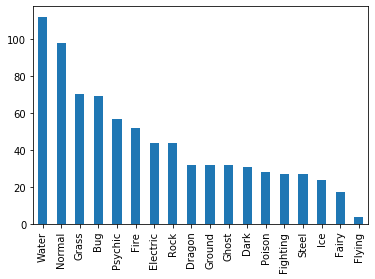

In [110]:
df['Type 1'].value_counts().plot(kind='bar')

### Groupby and Aggregation Function

The `groupby` function essentially splits the data into different groups depending upon the provided columns. The `groupby` method returns a Groupby object we can then use aggregate function to calculate the various values like sum, mean, count and son on using the `agg` method.

In [11]:
df['Type 1'].value_counts()

Type 1
Water       112
Normal       98
Grass        70
Bug          69
Psychic      57
Fire         52
Rock         44
Electric     44
Ground       32
Ghost        32
Dragon       32
Dark         31
Poison       28
Fighting     27
Steel        27
Ice          24
Fairy        17
Flying        4
Name: count, dtype: int64

In [15]:
df[df['Type 1']=='Water']['HP'].mean()

np.float64(72.0625)

In [16]:
df[df['Type 1']=='Grass']['HP'].mean()

np.float64(67.27142857142857)

In [12]:
df.groupby(by=['Type 1']).agg({'HP':"mean","Attack":"sum"}).reset_index()

,Type 1,HP,Attack
0,Bug,56.884058,4897
1,Dark,66.806452,2740
2,Dragon,83.312500,3588
3,Electric,59.795455,3040
4,Fairy,74.117647,1046
5,Fighting,69.851852,2613
6,Fire,69.903846,4408
7,Flying,70.750000,315
8,Ghost,64.437500,2361
9,Grass,67.271429,5125


We can also pass online function called `lambda` function as aggregate function. 

In [111]:
df.groupby(by=['Type 1']).agg({'HP':lambda x:max(x)-1,"Attack":"sum"}).reset_index()

,Type 1,HP,Attack
0,Bug,85,4897
1,Dark,125,2740
2,Dragon,124,3588
3,Electric,89,3040
4,Fairy,125,1046
5,Fighting,143,2613
6,Fire,114,4408
7,Flying,84,315
8,Ghost,149,2361
9,Grass,122,5125


### Time Series Analysis with Pandas

Pandas also provides various features that allows us to perform time series data analysis.

In [112]:
import pandas as pd
pd.to_datetime('2020-12-15 3:45pm')

Timestamp('2020-12-15 15:45:00')

As we can see from above example the `to_datetime` method is automatically infering the date and time based on the provided input.

We can use `date_range` function to generate time index.

In [113]:
pd.date_range('2018-01-01','2020-12-31')

DatetimeIndex(['2018-01-01', '2018-01-02', '2018-01-03', '2018-01-04',
               '2018-01-05', '2018-01-06', '2018-01-07', '2018-01-08',
               '2018-01-09', '2018-01-10',
               ...
               '2020-12-22', '2020-12-23', '2020-12-24', '2020-12-25',
               '2020-12-26', '2020-12-27', '2020-12-28', '2020-12-29',
               '2020-12-30', '2020-12-31'],
              dtype='datetime64[ns]', length=1096, freq='D')

In above example we generated DateTimeIndex from first Jan 2018 to last day december of 2020 for each day. We can use freq parameter to change it to monthly or quartely. For full list check this [link](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.to_timedelta.html)

We will use the Minimum Daily Temperatures Dataset which describes the minimum daily temperatures over 10 years (1981-1990) in the city Melbourne, Australia to show some features in pandas that can be useful while dealing with the time series data.

In [125]:
import pandas as pd

In [127]:
df = pd.read_csv('data/time_series.csv')

In [128]:
df.head()

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


Converting the date in the csv to Pandas date tinme objects. 

In [129]:
df['Date']=pd.to_datetime(df['Date'])

Lets set the date column as index and plot the data 

In [130]:
df = df.set_index('Date')

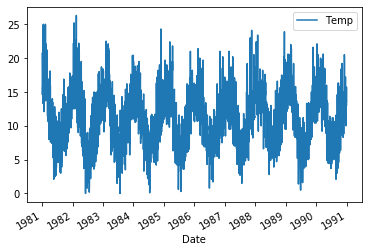

In [131]:
df.plot()

#### Rolling

Rolling is a useful feature while dealing with the time series data. Rolling is a process in which we create a rolling window with a given size and perform calculation on the data of this windows then we roll it through the data.

In [136]:
df.head()

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


In [139]:
new_df = df['Temp'].rolling(3).mean()

In [141]:
new_df.head(20)

Date
1981-01-01          NaN
1981-01-02          NaN
1981-01-03    19.133333
1981-01-04    17.100000
1981-01-05    16.400000
1981-01-06    15.400000
1981-01-07    15.800000
1981-01-08    16.333333
1981-01-09    18.333333
1981-01-10    19.733333
1981-01-11    19.333333
1981-01-12    16.500000
1981-01-13    15.400000
1981-01-14    17.166667
1981-01-15    21.066667
1981-01-16    22.400000
1981-01-17    22.100000
1981-01-18    22.033333
1981-01-19    21.033333
1981-01-20    19.333333
Name: Temp, dtype: float64

In the above example, the mean is taken from three rows (2 above it and 1 itself). For first two rows the value is NaN since they do not gave two rows above them for the third one the average temperature of 1981-01-01 (20.7), 1981-01-02 (17.9) and 1981-01-03 (18.8) which is 19.133 is returned. The windows moves one step down and process continues. 

## Conclusion

This notebook introduced **pandas**: **Series** and **DataFrame**, common ways to **read CSV, Excel (.xlsx), Parquet, and ODS**, and patterns you will reuse when cleaning and analyzing tabular data. Keep the [official documentation](https://pandas.pydata.org/docs/) open while you experiment.